/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

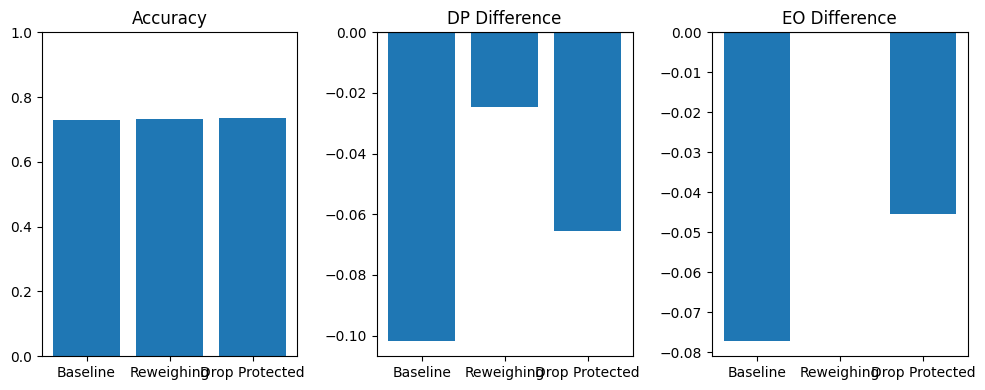

In [1]:
# ============================
# German Credit Fairness Pipeline (One Page)
# ============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ============================
# 1. LOAD DATA
# ============================

cols = [
    "status", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment", "installment_rate", "personal_status_sex",
    "other_debtors", "residence_since", "property", "age",
    "other_installment_plans", "housing", "existing_credits", "job",
    "people_liable", "telephone", "foreign_worker", "target"
]

df = pd.read_csv("german.csv", sep=" ", header=None)
df.columns = cols

# Convert target: 1 = good, 0 = bad
df["y"] = np.where(df["target"] == 1, 1, 0)

# ============================
# 2. PROTECTED ATTRIBUTES
# ============================

def extract_sex(code):
    if code in ["A91", "A93", "A94"]:
        return "male"
    else:
        return "female"

df["sex"] = df["personal_status_sex"].apply(extract_sex)
df["age_group"] = np.where(df["age"] <= 25, "young", "old")

# ============================
# 3. TRAIN/TEST SPLIT
# ============================

feature_cols = cols[:-1]  # all except target
X = df[feature_cols]
y = df["y"]
A_sex = df["sex"]

cat_cols = [
    "status", "credit_history", "purpose", "savings", "employment",
    "personal_status_sex", "other_debtors", "property",
    "other_installment_plans", "housing", "job", "telephone", "foreign_worker"
]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

X_train, X_test, y_train, y_test, sex_train, sex_test = train_test_split(
    X, y, A_sex, test_size=0.3, random_state=42, stratify=y
)

# ============================
# 4. FAIRNESS METRICS
# ============================

def fairness_metrics(y_true, y_pred, protected, privileged="male"):
    priv = (protected == privileged)
    unpriv = ~priv

    dp = y_pred[unpriv].mean() - y_pred[priv].mean()

    def tpr(mask):
        idx = (y_true == 1) & mask
        return y_pred[idx].mean() if idx.sum() > 0 else np.nan

    eo = tpr(unpriv) - tpr(priv)

    return dp, eo

# ============================
# 5. BASELINE MODEL
# ============================

baseline = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000))
])

baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
dp_base, eo_base = fairness_metrics(y_test.values, y_pred_base, sex_test.values)

# ============================
# 6. INTERVENTION 1: REWEIGHING
# ============================

def compute_reweighing_weights(protected, y):
    df_tmp = pd.DataFrame({"A": protected, "y": y})
    p_y = df_tmp["y"].value_counts(normalize=True)
    p_A = df_tmp["A"].value_counts(normalize=True)
    p_Ay = df_tmp.groupby(["A", "y"]).size() / len(df_tmp)

    weights = []
    for a, yv in zip(df_tmp["A"], df_tmp["y"]):
        weights.append((p_A[a] * p_y[yv]) / p_Ay[(a, yv)])
    return np.array(weights)

w_train = compute_reweighing_weights(sex_train.values, y_train.values)

reweigh = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000))
])

reweigh.fit(X_train, y_train, clf__sample_weight=w_train)
y_pred_rw = reweigh.predict(X_test)

acc_rw = accuracy_score(y_test, y_pred_rw)
dp_rw, eo_rw = fairness_metrics(y_test.values, y_pred_rw, sex_test.values)

# ============================
# 7. INTERVENTION 2: DROP PROTECTED ATTRIBUTES
# ============================

feature_cols2 = [c for c in feature_cols if c not in ["personal_status_sex", "age"]]
X2 = df[feature_cols2]

cat_cols2 = [c for c in cat_cols if c in feature_cols2]
num_cols2 = [c for c in feature_cols2 if c not in cat_cols2]

preprocess2 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols2),
    ("num", "passthrough", num_cols2)
])

X2_train, X2_test, y2_train, y2_test, sex2_train, sex2_test = train_test_split(
    X2, y, A_sex, test_size=0.3, random_state=42, stratify=y
)

drop = Pipeline([
    ("prep", preprocess2),
    ("clf", LogisticRegression(max_iter=1000))
])

drop.fit(X2_train, y2_train)
y_pred_drop = drop.predict(X2_test)

acc_drop = accuracy_score(y2_test, y_pred_drop)
dp_drop, eo_drop = fairness_metrics(y2_test.values, y_pred_drop, sex2_test.values)

# ============================
# 8. RESULTS + VISUALIZATION
# ============================

models = ["Baseline", "Reweighing", "Drop Protected"]
accs = [acc_base, acc_rw, acc_drop]
dp = [dp_base, dp_rw, dp_drop]
eo = [eo_base, eo_rw, eo_drop]

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.bar(models, accs); plt.title("Accuracy"); plt.ylim(0,1)

plt.subplot(1,3,2)
plt.bar(models, dp); plt.title("DP Difference"); plt.axhline(0,color='black')

plt.subplot(1,3,3)
plt.bar(models, eo); plt.title("EO Difference"); plt.axhline(0,color='black')

plt.tight_layout()
plt.show()